# Tarea N°1: Desempeño de Modulaciones en un Canal Óptico con Ruido AWGN

El objetivo de esta Tarea, consiste en analizar y comparar la robustez de distintos esquemas de modulación digital (más específicamente: PAM-2, PAM-4, QPSK, 16-QAM y 8-PSK) frente al nivel de ruido existente en cualquier canal de comunicaciones, aunque en nuestro contexto, se busca analizar como canal una fibra óptica.  

Para completar esta tarea, se hizo una reestructuración del código "modulations.py" que fue provisto como material de estudio para este curso y se mejoró implementando una simulación de Montecarlo que modela la transmisión de símbolos aleatorios a través de un canal afectado por Ruido Blanco Gaussiano Aditivo (AWGN). El objetivo principal es trazar las clásicas "curvas de cascada", que grafican la Tasa de Error de Bit (BER) en función de la Relación Señal a Ruido (SNR).

Para ello se propone realizar un código en Python que se corresponda con el siguiente diagrama en bloques:

<div align="center">
    <img src="Diagrama en bloques.png" width="800">
</div>

Se tiene que de este diagrama en bloques, se identifican las siguientes partes:

1. **Generación del Símbolo ($a_{k}$):** Esta parte genera una serie de simbolos aleatorios de acuerdo al diagrama de constelaciones elegido para cada modulación, es decir que por ejemplo para $PAM-2$, los simbolos unicamente pueden ser iguales a: $a_{K} = -1 ; 1$.

2. **Canal AWGN ($n_{k}$):** Para modelar las perdidas del enlace de fibra óptica, se realiza un inyección de Ruido Blanco Gaussiano Aditivo (AWGN) a los simbolos $a_{K}$.

3. **Recepción ($y_{k}$):** El resultado de la suma entre $a_{k}$ y $n_{k}$, es guardado dentro de la variable $y_{k}$, siendo este el símbolo perturbado recibido por el detector.

4. **Slicer ($a'_{k}$):** Este bloque se encarga de tomar la decisión de a que simbolo se corresponde su entrada ($y_{k}$) de acuerdo al diagrama de constelaciones elegido para cada modulación, es decir que toma la decisión sobre que valor de $y_{k}$ se corresponde a los valores de la constelación dados por $a_{k}$. Para ello se estima la Distancia Euclidiana Mínima entre un $y_{k}$ y el valor de $a_{k}$ mas cercano y el resultado, se guarda en una variable denominada $a'_{k}$

5. **Contador de Errores:** Nótese que dado que es una simulación, podemos realizar una comparación entre el símbolo que se mando al canal ($a_{k}$) y el simbolo que se recibe del otro lado del canal ($a'_{k}$), dandonos así una noción del Symbol Error Rate (SER) definido por:

$$
    SER = \frac{\# Símbolos Erroneos}{\# Símbolos}
$$

De aquí, sabiendo que si definimos a la constante $k$ como:

$$
    log_{2}(M) = k \ \left[\frac{bits}{símbolo}\right]
$$

Con $M$ siendo la cantidad de niveles o simbolos de la modulación, se tiene que el Bit Error Rate estará dado por:

$$
    BER = \frac{\# Bits Erroneos}{\# Bits} = \frac{\# Bits Erroneos}{k \# Simbolos} \approx \frac{SER}{k}
$$

Esta aproximación sólo es válida para cuando: $\# Bits Erroneos \approx \# Símbolos Erroneos$. Para comenzar nuestra simulación, se debe primero definir las librerias de trabajo utilizadas, tal como muestra el siguiente código:

In [36]:
import numpy as np
from numpy.fft import fft, fftshift
import matplotlib.pyplot as plt
from scipy import signal
from scipy.special import erfc


plt.close('all')

### Motor de Simulación: La función `run_simulation()`

Para realizar tal tarea, se propone definir a una función núcleo de nuestro análisis, la cual encapsulará toda la lógica del diagrama en bloques visto anteriormente para que pueda ser reutilizada iterativamente, dependiendo de las siguientes variables:

* `mod_type`: Consiste en un string que define el esquema de modulación a utilizar y consecuentemente, como son los simbolos del sistema.

* `snr_db_range`: Se define a un arreglo de números con el rango de valores de SNR en $[dB]$ para los cuale se medirán el $BER$ y $SER$.

* `L`: La cantidad de símbolos a transmitir por cada valor de SNR. Siguiendo la consigna propuesta en clase, se propone utilizar siempre $L = 100000 \ [Símbolos]$.

Una vez definidos los parámetros de entrada de esta función, veamos en términos generales, cual es la lógica interna y consideraciones clave a la hora de analizar esta función:
1. **Normalización de Energía:** Se independiza del tamaño o la forma de la constelación, ya que el código ajusta los símbolos para que la potencia promedio transmitida sea siempre de 1 ($P_{s} = 1 \ [dB]$), garantizando así que la comparación entre modulaciones sea posible.

2. **Dimensionalidad del Ruido:** Se tiene que dado que las modulaciones $PAM$ son unidimencionales, el ruido solo les afecta en el eje real del diagrama de constelaciones. Sim embargo para modulaciones bidimensionales, tales como $PSK$ o $QAM$, el ruido se debe dividir en cuadratura de modo que afecte a las componentes reales e imaginarias del mismo, es decir que:

$$
    n_{k} = n_{k}^{(Real)} + j n_{k}^{(Imag.)} 
$$

Nótese entonces que cada una de estas componentes serán iguales a: $\frac{P_{n}}{2}$.

3. **Slicer por Distancia Mínima:** Para facilitar un engorroso calculo y diseño de condiciones lógicas dadas del diagrama de constelaciones, se optó que el bloque del Slicer mida la distancia entre la señal recibida ($y_{k}$) y todos los puntos ideales de la constelación. Luego, el símbolo que se encuentre a la menror distancia euclidiana (implementado eficientemente mediante *broadcasting* de NumPy), será el simbolo que interprete el Slicer y que guardara como salida ($a'_{k}$).

4. **Estimación de BER:** Si se asume un diagrama de constelaciones para cada modulación ideal, es posible estimar el BER siguiendo dividiendo la Tasa de Error de Símbolo (SER) por la cantidad de bits por símbolo ($k$), siguiendo las formulas desarrolladas en la sección precedente.

In [37]:
#  Se simula un canal optico de transmisión y recepción para una modulación dada, calculando la BER aproximada para un rango de valores SNR.

def run_simulation(mod_type, snr_db_range, L=100000):
       
    # Definición del diagrama de constelación (a_k)
    if mod_type == 'PAM-2':
        const = np.array([-1, 1])
        M = 2
    elif mod_type == 'PAM-4':
        const = np.array([-3, -1, 1, 3])
        M = 4
    elif mod_type == 'QPSK':
        const = np.array([1+1j, 1-1j, -1+1j, -1-1j])
        M = 4
    elif mod_type == '16-QAM':
        val = np.array([-3, -1, 1, 3])
        const = np.array([x + 1j*y for x in val for y in val])      # Combinamos todas las permutaciones reales e imaginarias
        M = 16
    elif mod_type == '8-PSK':
        # Puntos distribuidos en un círculo unitario
        const = np.exp(1j * 2 * np.pi * np.arange(8) / 8)
        M = 8
    else:
        raise ValueError("Modulación no soportada")

    # Se calcula la constante K
    k = int(np.log2(M))

    # Normalización de energía: Aseguramos que la potencia promedio (Ps) sea 1
    const = const / np.sqrt(np.mean(np.abs(const)**2))
    Ps = 1.0

    ber_list = []

    for snr_db in snr_db_range:
        # 1. Generación de A_k aleatorios (Índices y luego los símbolos complejos/reales)
        sym_idx = np.random.randint(0, M, L)
        symbols = const[sym_idx]                                    # Estos son los A_k reales enviados

        # 2. Modelado del ruido AWGN (n_k)
        snr_linear = 10**(snr_db / 10)
        Pn = Ps / snr_linear

        # Repartición de la Potencia de ruido de acuerdo a la modulación (Recuerde que PAM es 1D (solo real), QAM/PSK es 2D (complejo))
        if 'PAM' in mod_type:
            noise = np.sqrt(Pn) * np.random.randn(L)
        else:
            noise = np.sqrt(Pn/2) * (np.random.randn(L) + 1j * np.random.randn(L))

        # 3. Señal en el receptor (y_k = A_k + n_k)
        y_k = symbols + noise

        # 4. Bloque Slicer (Decisor por Distancia Mínima)
        # Broadcasting de NumPy para calcular distancias de cada señal recibida a todos los puntos ideales
        distances = np.abs(y_k[:, None] - const[None, :])
        
        # El índice de la distancia mínima nos dice qué símbolo se decidió (A'_k)
        idx_hat = np.argmin(distances, axis=1)

        # 5. Bloque Count (Cálculo de Errores)
        errores_simbolos = np.sum(idx_hat != sym_idx)
        SER = errores_simbolos / L
        
        # Aproximación de BER asumiendo Codificación Gray (BER = SER / k)
        BER_aprox = SER / k 
        
        # Guardamos un mínimo para que los gráficos logarítmicos no rompan si da 0 errores
        if BER_aprox == 0:
            BER_aprox = 1e-6                                        # Limite inferior para L=100k
            
        ber_list.append(BER_aprox)

    return np.array(ber_list)

### Verificación mediante la BER Teórica

Al igual que como se realizó en el código de ejemplo, se propone que para válidar los resultados obtenidos de la simulación de Montecarlo precedente, se recurre al modelado analítico de la probabilidad de error. Para ello, se tiene que en sistemas afectados por Ruido Blanco Gaussiano Aditivo (AWGN), la probabilidad de que el ruido blanco, desplace un símbolo más allá de su frontera de decisión en el receptor, es modelado estadísticamente utilizando una **Power Density Function** (PDF) gaussiana definida por:

$$
    PDF(u) = \frac{1}{\sqrt{2\pi}} e^{-\frac{u^2}{2}}
$$

Se tiene entonces que para una distribución estándar, esta función nos indica la probabilidad de que el ruido tome un valor específico, dibujando el contorno de la clásica "campana de Gauss". Sin embargo, para que nuestro  slicer cometa un error, no es de interés que el ruido tome un valor exacto, sino que su magnitud sea lo suficientemente grande como para cruzar la frontera de decisión. Esta probabilidad de cruzar el úmbral equivale al **área bajo la cola de la PDF**  desde la distancia al umbral $x$ hacia el infinito. A esta integral se la conoce formalmente como la **función $Q(x)$** la cual se define como:

$$
    Q(x) = \int_{x}^{\infty} PDF(u) \ du = \int_{x}^{\infty} \frac{1}{\sqrt{2\pi}} e^{-\frac{u^2}{2}} \ du
$$

En términos prácticos y de cómputo numérico (como en las librerías científicas de Python), la función $Q(x)$ se relaciona directamente con la función error complementaria (`erfc`) de la siguiente manera:

$$Q(x) = \frac{1}{2} \text{erfc}\left(\frac{x}{\sqrt{2}}\right)$$

Para calcular entonces la BER Teórica, se propone normalizar la energía promedio de todas las constelaciones para que la energía de símbolo sea igual a: $E_{s} = 1$. Por lo tanto, la variable de relación señal a ruido en escala lineal ($SNR$) equivale directamente a $\frac{E_{s}}{N_{0}}$, siendo esta última la energía del símbolo sobre la densidad espectral de potencia del ruido. A continuación, se detallan las expresiones teóricas para cada modulación:

* **PAM-2 y QPSK:** Dado que $QPSK$ puede interpretarse como dos transmisiones $PAM-2$ ortogonales e independientes que comparten la mitad de la potencia y sufren la mitad de la varianza del ruido, el desempeño frente a la relación $E_{s}/N_{0}$ es idéntico para la tasa de error de bit. La ecuación teórica exacta es:
$$
    BER_{PAM2} = BER_{QPSK} = Q\left(\sqrt{SNR}\right)
$$

* **PAM-4 y 16-QAM:** Al normalizar la energía de la constelación PAM-4 (con: $k = 2$), la distancia euclidiana entre símbolos se reduce, lo que aumenta la probabilidad de error. La aproximación de la $SER$ promedia los errores de los símbolos internos (que tienen fronteras en ambos lados) y los externos. Dividiendo la $SER$ por $2$ obtenemos la $BER$. Para $16-QAM$ (donde: $k = 4$), al ser bidimensional, se comporta matemáticamente como dos señales $PAM-4$ ortogonales, por lo que su $BER$ responde a la misma aproximación:
$$
    BER_{PAM4} = BER_{16QAM} \approx \frac{3}{4} Q\left(\sqrt{\frac{SNR}{5}}\right)
$$

* **8-PSK:** En este esquema (donde: $k = 3$), los 8 símbolos están equiespaciados en una circunferencia. La distancia hacia las fronteras de decisión está dada por el seno de la mitad del ángulo entre símbolos adyacentes (es decir, $\frac{\pi}{8}$). Asumiendo que a valores de SNR razonables los errores ocurren casi exclusivamente hacia los dos vecinos más cercanos, la aproximación resulta en:
$$
    BER_{8PSK} \approx \frac{2}{3} Q\left(\sqrt{2 \cdot SNR} \cdot \sin\left(\frac{\pi}{8}\right)\right)
$$

In [ ]:
# Se define a la función Q(x) estándar para cálculo de probabilidad de error.
def Q(x):
    return 0.5 * erfc(x / np.sqrt(2))

# Con la Q(x) definida, se calcula la curva de BER teórica exacta o aproximada para una modulación dada en un canal AWGN.
def get_theoretical_ber(mod_type, snr_db_range):
    snr_linear = 10**(snr_db_range / 10)
    
    if mod_type == 'PAM-2':
        # BER = Q(sqrt(SNR))
        ber_theo = Q(np.sqrt(snr_linear))
        
    elif mod_type == 'QPSK':
        # BER = Q(sqrt(SNR))
        ber_theo = Q(np.sqrt(snr_linear))
        
    elif mod_type == 'PAM-4':
        # SER = 1.5 * Q(sqrt(SNR / 5)), BER = SER / 2
        ber_theo = 0.75 * Q(np.sqrt(snr_linear / 5))
        
    elif mod_type == '16-QAM':
        # SER = 3 * Q(sqrt(SNR / 5)), BER = SER / 4
        ber_theo = 0.75 * Q(np.sqrt(snr_linear / 5))
        
    elif mod_type == '8-PSK':
        # SER = 2 * Q(sqrt(2 * SNR) * sin(pi/8)), BER = SER / 3
        ser_theo = 2 * Q(np.sqrt(2 * snr_linear) * np.sin(np.pi / 8))
        ber_theo = ser_theo / 3
        
    else:
        raise ValueError("Modulación no soportada")
        
    return ber_theo

### Ejecución y Visualización de Resultados

En esta última etapa, configuramos los parámetros globales de la simulación y procedemos a ejecutar la simulación para todas las modulaciones solicitadas. Los parámetros a configurar son:
1. **Longitud de la secuencia ($L$):** Se utilizarón $L = 100000 \ [Símbolos.]$ dado como parte de la consigna. Además este valor nos otorga una resolución estadística suficiente para observar tasas de error del orden de $10^{-4}$ con un margen de confianza razonable.
2. **Rango SNR:** Se barrerá desde $0 \ [dB]$ (condición extremadamente ruidosa) hasta $20 \ [dB]$ (canal limpio) en pasos de $1 \ [dB]$.

Finalmente, se grafican los resultados de la $BER_{Simulada}$ y la $BER_{Teórica}$ con respecto a la $SNR$, utilizando una escala logarítmica para el eje Y (BER) siendo esta una representación estándar en la industria de las telecomunicaciones ópticas, ya que permite observar visualmente el compromiso entre la eficiencia espectral (cantidad de bits por símbolo) y la robustez frente al ruido.

Iniciando simulación para 100000 símbolos por punto de SNR...
Simulando y calculando teoría para PAM-2...
Simulando y calculando teoría para PAM-4...
Simulando y calculando teoría para QPSK...
Simulando y calculando teoría para 8-PSK...
Simulando y calculando teoría para 16-QAM...


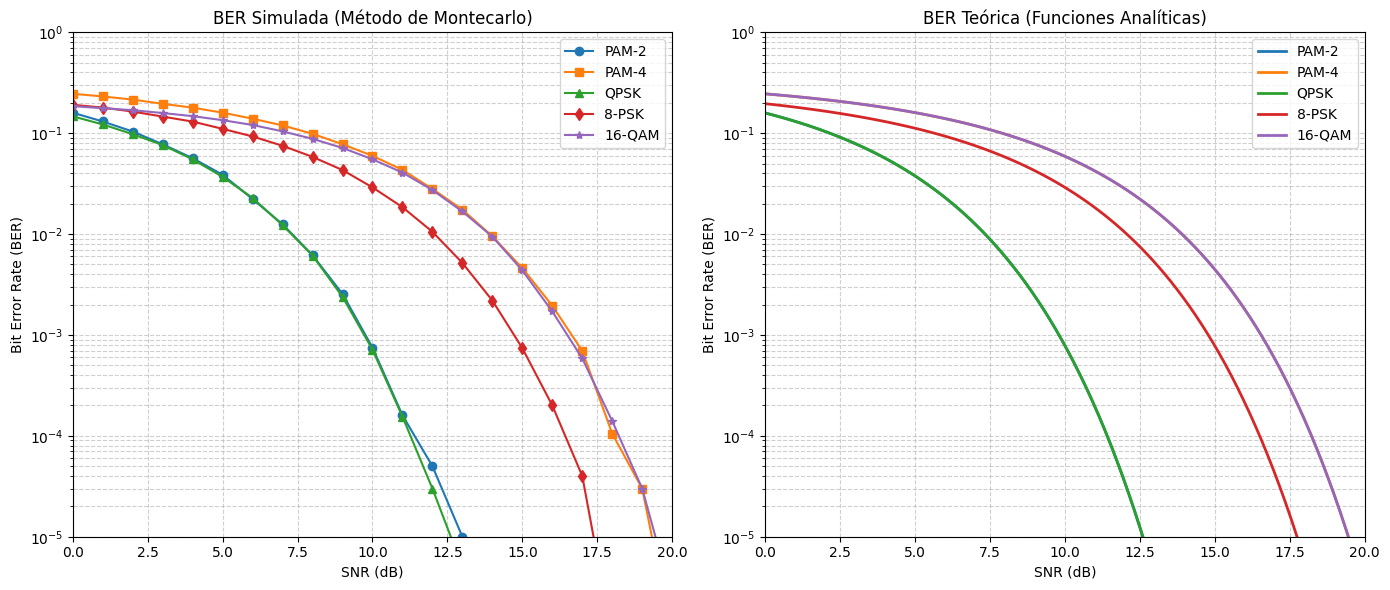

In [40]:
# -------------------------------
# Configuración Principal y Gráficos (Ejes Y independientes)
# -------------------------------
L_simulacion = 100000
rango_snr_db = np.arange(0, 21, 1) 
rango_snr_db_theo = np.linspace(0, 20, 100) 

modulaciones = ['PAM-2', 'PAM-4', 'QPSK', '8-PSK', '16-QAM']
resultados_ber_sim = {}
resultados_ber_theo = {}

print(f"Iniciando simulación para {L_simulacion} símbolos por punto de SNR...")

for mod in modulaciones:
    print(f"Simulando y calculando teoría para {mod}...")
    resultados_ber_sim[mod] = run_simulation(mod, rango_snr_db, L=L_simulacion)
    resultados_ber_theo[mod] = get_theoretical_ber(mod, rango_snr_db_theo)

# Quitamos 'sharey=True' para que cada gráfico tenga sus propios números en el eje Y
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

marcadores = ['o', 's', '^', 'd', '*']
colores = plt.cm.tab10.colors 

# --- PLOT 1: BER Simulada (Izquierda) ---
for i, mod in enumerate(modulaciones):
    ax1.semilogy(rango_snr_db, resultados_ber_sim[mod], marker=marcadores[i], 
                 linestyle='-', color=colores[i], label=mod)

ax1.set_title('BER Simulada (Método de Montecarlo)')
ax1.set_xlabel('SNR (dB)')
ax1.set_ylabel('Bit Error Rate (BER)')
ax1.set_ylim(1e-5, 1) 
ax1.set_xlim(0, 20)
ax1.grid(True, which="both", ls="--", alpha=0.6)
ax1.legend()

# --- PLOT 2: BER Teórica (Derecha) ---
for i, mod in enumerate(modulaciones):
    ax2.semilogy(rango_snr_db_theo, resultados_ber_theo[mod], 
                 linestyle='-', linewidth=2, color=colores[i], label=mod)

ax2.set_title('BER Teórica (Funciones Analíticas)')
ax2.set_xlabel('SNR (dB)')
ax2.set_ylabel('Bit Error Rate (BER)') # Agregamos la etiqueta del eje Y
ax2.set_ylim(1e-5, 1) # Forzamos los mismos límites que el ax1
ax2.set_xlim(0, 20)
ax2.grid(True, which="both", ls="--", alpha=0.6)
ax2.legend()

# Ajustamos el layout 
plt.tight_layout()
plt.show()

### Conclusiones

A partir de los resultados obtenidos en la simulación de Montecarlo y su posterior contrastación con el modelado analítico, podemos extraer las siguientes conclusiones sobre el desempeño de las modulaciones en canales ópticos simulados con AWGN:

* **Validación del Modelo (Teoría vs. Simulación):** Se observó en esta última sección una gran similitud entre las curvas teóricas (líneas continuas) y los resultados simulados (marcadores), lo que demuestra entonces que el modelado del canal, la normalización de las energías y la lógica de decisión del slicer fueron implementados correctamente en esta simulación. Nótese tambien que la gráfica de la $BER_{Teórica}$ con respecto a la $SNR$ nos permite encontrar una limitación del modelo de Montecarlo: En regiones de alta $SNR$ (donde la curva simulada cae a cero abruptamente por no registrar errores en la ventana de $100000 \ [Símbolos]$), las funciones matemáticas nos permiten predecir el comportamiento de la cascada hacia el infinito.

* **El compromiso (Trade-off) fundamental:** La segunda conclusión que se puede determinar de observar las gráficas es el *trade-off* que existe, ya que al incrementar la eficiencia espectral (es decir que transmitimos más bits por símbolo) se paga con un costo directo en la robustez del enlace. Nótese que los esquemas de orden superior (Como $QAM-16$ o $8-PSK$) que aglomeran más puntos en el mismo espacio de energía, requieren entonces de una $SNR$ significativamente mayor para mantener la misma $BER$ que esquemas más simples como lo pueden ser el $PAM-2$.

* **La ventaja geométrica de la bidimensionalidad:** Si observamos modulaciones que comparten la misma capacidad de modular información tales como PAM-4 y QPSK (ambas transmiten 2 bits por símbolo), se evidencia que la gráfica muestra una clara superioridad de $QPSK$ frente al ruido. Esto ocurre porque $QPSK$ distribuye sus símbolos en un plano complejo (dado por $I$ y $Q$), maximizando la distancia euclidiana entre ellos, mientras que $PAM-4$ está forzada a ubicarlos en un único eje unidimensional, acercándolos peligrosamente entre sí.

* **Equivalencia matemática:** El solapamiento de las curvas corrobora la teoría subyacente de las telecomunicaciones: el desempeño frente al ruido de $PAM-2$ es idéntico al de $QPSK$, y el de $PAM-4$ coincide con el de $QAM-16$. En esencia, el canal optico con ruido afecta de la misma manera a un esquema complejo que a dos esquemas PAM ortogonales e independientes entre sí.

* **Aplicación práctica en el mundo real:** Esta simulación justifica las arquitecturas de red actuales. Para enlaces ópticos coherentes de larga distancia (Long-Haul), la industria elige esquemas bidimensionales robustos como QPSK o QAM para tolerar el ruido acumulado por los amplificadores. En contraparte, modulaciones menos robustas pero más económicas de implementar en detección directa, como PAM-4, son el estándar para conexiones de muy corta distancia (Short-Reach), como las interconexiones dentro de los centros de datos.